<a href="https://colab.research.google.com/github/Ash100/AIMe/blob/main/FEL_Kinetics_Analysis_PagC_Binders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Free Energy Landscape (FEL) & Kinetics Analysis
## PagC-ECD &mdash; De Novo Binder Complexes (Rank1&ndash;Rank4)

This notebook performs a manuscript-grade kinetics / Free Energy Landscape analysis on four
receptor&ndash;binder complexes simulated in OpenMM (Google Colab). Each complex contains:

- **Receptor**: Extracellular domain (ECD) of PagC &mdash; residues **1&ndash;162**
- **Binder**: de novo designed binder &mdash; residues **163 and beyond**

Chain IDs are not present in the topology/trajectory, so receptor and binder are defined
by **residue index** throughout this notebook (no chain-ID dependency anywhere).

### What this notebook computes
1. Backbone RMSD (complex, receptor-only, binder-only) &mdash; trajectory stability
2. Interface RMSD (binder pose after receptor-only superposition) &mdash; the key "binding behavior" metric
3. Radius of gyration (Rg) &mdash; global compactness
4. 2D Free Energy Landscapes: **RMSD vs Rg** and **RMSD vs Interface-RMSD**, in kcal/mol
5. Per-residue RMSF &mdash; flexibility, with interface residues flagged
6. Interface contact analysis (heavy-atom contacts within 4.5 &Aring;, H-bonds, contact-area proxy)
7. Top-5 lowest free-energy frames per complex, extracted as standalone PDBs
8. Cross-complex ranking summary &mdash; which complex behaves best overall
9. Publication figures at 600 DPI (PNG + vector PDF) saved to `/content/outputs/figures`

### Before you run
- This notebook expects your **PDB (topology) + DCD (trajectory)** pairs on Google Drive,
  one pair per complex (Rank1&ndash;Rank4).
- Edit only the **`CONFIG`** cell below &mdash; everything after is generic and driven by it.
- Runtime: GPU is *not* required (no force evaluation here); a standard CPU runtime is
  sufficient. A high-RAM runtime helps only if your DCDs are very large.


## 1. Environment setup

In [1]:
# @title 1.1 Install dependencies (run once per session)
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    pip_name = pip_name or pkg
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)

for pkg, pip_name in [
    ("MDAnalysis", "MDAnalysis"),
    ("sklearn", "scikit-learn"),
    ("seaborn", "seaborn"),
    ("scipy", "scipy"),
    ("tqdm", "tqdm"),
]:
    _ensure(pkg, pip_name)

print("All dependencies are available.")


All dependencies are available.


In [2]:
# @title 1.2 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# @title 1.3 Imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import seaborn as sns

import MDAnalysis as mda
from MDAnalysis.analysis import align, rms, pca
from MDAnalysis.analysis.distances import distance_array
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

from scipy.stats import gaussian_kde

from tqdm.auto import tqdm

# ---- manuscript-grade plotting defaults ----
plt.rcParams.update({
    "figure.dpi": 150,             # on-screen preview only; exports use savefig dpi=600
    "savefig.dpi": 600,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,            # editable text in vector PDF (Illustrator-safe)
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})
sns.set_style("ticks")

print("MDAnalysis version:", mda.__version__)


MDAnalysis version: 2.10.0


## 2. Configuration

**This is the only cell you should need to edit.** Fill in your Google Drive paths for each
complex's PDB (topology) and DCD (trajectory). Add/remove dictionary entries if you have
more or fewer than four complexes &mdash; everything downstream loops over this dict.

`RECEPTOR_LAST_RESID` is the last residue index (1-based, as in your PDB `resid` field) that
belongs to the PagC-ECD receptor. Everything with a higher `resid` is treated as binder.
If your numbering is not a clean contiguous 1..N (e.g. there's a gap, or binder numbering
restarts from 1), edit `RECEPTOR_SEL` / `BINDER_SEL` directly instead of relying on the cutoff.


In [4]:
# @title 2.1 CONFIG — EDIT THIS CELL

# ---------------------------------------------------------------------------
# Path setup: one entry per complex. Keys are used as labels everywhere
# (plot legends, file names, output folders).
# ---------------------------------------------------------------------------
COMPLEXES = {
    "Rank1": {
        "pdb": "/content/drive/MyDrive/PagC/PagC1_Repeat/PagC1_equil.pdb",
        "dcd": "/content/drive/MyDrive/PagC/PagC1_Repeat/PagC1_prod1-10_whole.dcd",
    },
    "Rank2": {
        "pdb": "/content/drive/MyDrive/PagC/PagC2/SYS.pdb",
        "dcd": "/content/drive/MyDrive/PagC/PagC2/PagC2_prod1-10_whole.dcd",
    },
    "Rank3": {
        "pdb": "/content/drive/MyDrive/PagC/PagC3/SYS.pdb",
        "dcd": "/content/drive/MyDrive/PagC/PagC3/PagC3_prod1-10_whole.dcd",
    },
    "Rank4": {
        "pdb": "/content/drive/MyDrive/PagC/PagC4_equil.pdb",
        "dcd": "/content/drive/MyDrive/PagC/PagC4_prod1-10_whole.dcd",
    },
}

# ---------------------------------------------------------------------------
# Residue-based receptor / binder definition (NO chain IDs needed).
# Receptor = resid 1..RECEPTOR_LAST_RESID ; Binder = everything after.
# ---------------------------------------------------------------------------
RECEPTOR_LAST_RESID = 162

# MDAnalysis selection strings built from the cutoff above.
# If your residue numbering is NOT a clean contiguous 1..N (e.g. binder resid
# restarts at 1, or there's an insertion/gap), replace these two strings with
# explicit selections, e.g. "resid 1-162" / "resid 163-300", and ignore
# RECEPTOR_LAST_RESID elsewhere.
RECEPTOR_SEL = f"resid 1-{RECEPTOR_LAST_RESID} and protein"
BINDER_SEL   = f"resid {RECEPTOR_LAST_RESID + 1}-99999 and protein"

# ---------------------------------------------------------------------------
# Trajectory handling
# ---------------------------------------------------------------------------
STRIDE = 1                  # set >1 to subsample long trajectories for speed (e.g. 2, 5)
INTERFACE_CUTOFF_A = 4.5    # heavy-atom contact cutoff (Angstrom) defining the binding interface
N_TOP_FRAMES = 5            # number of lowest-FEL frames to extract per complex

# ---------------------------------------------------------------------------
# Free energy landscape settings
# ---------------------------------------------------------------------------
TEMPERATURE_K = 300.0        # simulation temperature, used to convert -ln(P) into kcal/mol
KDE_GRID_POINTS = 150        # FEL grid resolution per axis
KDE_BANDWIDTH = None         # None = Scott's rule (scipy default); float to override

# ---------------------------------------------------------------------------
# Output locations
# ---------------------------------------------------------------------------
OUTPUT_ROOT = "/content/outputs"
FIG_DIR   = os.path.join(OUTPUT_ROOT, "figures")
DATA_DIR  = os.path.join(OUTPUT_ROOT, "data")
FRAME_DIR = os.path.join(OUTPUT_ROOT, "lowest_energy_frames")
for d in (FIG_DIR, DATA_DIR, FRAME_DIR):
    os.makedirs(d, exist_ok=True)

# Consistent color per complex across every figure in the notebook
PALETTE = sns.color_palette("colorblind", n_colors=max(4, len(COMPLEXES)))
COLORS = {name: PALETTE[i] for i, name in enumerate(COMPLEXES)}

print(f"{len(COMPLEXES)} complexes configured: {list(COMPLEXES.keys())}")
print(f"Receptor selection: '{RECEPTOR_SEL}'")
print(f"Binder selection:   '{BINDER_SEL}'")
print(f"Outputs will be written under: {OUTPUT_ROOT}")


4 complexes configured: ['Rank1', 'Rank2', 'Rank3', 'Rank4']
Receptor selection: 'resid 1-162 and protein'
Binder selection:   'resid 163-99999 and protein'
Outputs will be written under: /content/outputs


### 2.2 Diagnose file pairing before loading anything paired

If you ever see an error like *"topology and trajectory don't have the same number of
atoms"*, run this cell first. It inspects each PDB and each DCD **independently** (it never
pairs them), so you can see exactly which file is the outlier and why — typically one of:

- the **DCD carries explicit water/ions** while the **PDB is a stripped protein-only file**
  (or vice versa) — the most common cause, and an easy fix (see below);
- the PDB and DCD genuinely belong to **different complexes** (a path was swapped on Drive);
- the DCD has a **periodic box / extra dummy atoms** the PDB doesn't.

This cell does not require the pairs to match, so it will run even when 2.3 below fails.


In [5]:
# @title 2.2a Inspect each PDB and DCD independently (no pairing)
import MDAnalysis as mda

diag_rows = []
for name, paths in COMPLEXES.items():
    row = {"complex": name}
    try:
        u_top = mda.Universe(paths["pdb"])
        row["pdb_n_atoms"] = len(u_top.atoms)
        row["pdb_n_residues"] = len(u_top.residues)
    except Exception as e:
        row["pdb_n_atoms"] = f"ERROR: {e}"
        row["pdb_n_residues"] = "-"

    try:
        # Load the DCD on its own with a minimal reader just to read n_atoms
        # from the trajectory header, without requiring it to match any topology.
        from MDAnalysis.coordinates.DCD import DCDReader
        dcd_reader = DCDReader(paths["dcd"])
        row["dcd_n_atoms"] = dcd_reader.n_atoms
        row["dcd_n_frames"] = dcd_reader.n_frames
        dcd_reader.close()
    except Exception as e:
        row["dcd_n_atoms"] = f"ERROR: {e}"
        row["dcd_n_frames"] = "-"

    diag_rows.append(row)

diag_df = pd.DataFrame(diag_rows)
diag_df["atoms_match"] = diag_df.apply(
    lambda r: (isinstance(r["pdb_n_atoms"], (int, float))
               and isinstance(r["dcd_n_atoms"], (int, float))
               and r["pdb_n_atoms"] == r["dcd_n_atoms"]),
    axis=1,
)
display(diag_df)

mismatches = diag_df[~diag_df["atoms_match"]]
if len(mismatches):
    print("\nMISMATCHES FOUND:")
    for _, r in mismatches.iterrows():
        print(f"  {r['complex']}: PDB={r['pdb_n_atoms']} atoms, DCD={r['dcd_n_atoms']} atoms")
    print("\nIf DCD > PDB and the ratio is roughly 1.3-4x, your DCD almost certainly "
          "still has water/ions that your PDB topology doesn't. Two fixes:\n"
          "  (A) Re-save/re-export a topology PDB from the SAME solvated system used "
          "to write the DCD (e.g. write frame 0 of the solvated system to PDB in your "
          "OpenMM script), OR\n"
          "  (B) Strip solvent from the DCD before analysis (see optional cell 2.2b below) "
          "if you only saved a solvated DCD but have a protein-only PDB.\n"
          "If the files are NOT a solvent mismatch (e.g. wildly different atom counts "
          "with no clean ratio), double check the Drive paths in CONFIG — you may have "
          "two complexes' files crossed.")
else:
    print("\nAll PDB/DCD pairs have matching atom counts. Safe to proceed to 2.3.")


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


,complex,pdb_n_atoms,pdb_n_residues,dcd_n_atoms,dcd_n_frames,atoms_match
0,Rank1,54572,10000,54572,1000,True
1,Rank2,76855,24596,76855,1000,True
2,Rank3,72896,23354,72896,1000,True
3,Rank4,64303,10000,64303,1000,True



All PDB/DCD pairs have matching atom counts. Safe to proceed to 2.3.


In [6]:
# @title 2.2b OPTIONAL: strip solvent/ions from a DCD to match a protein-only PDB
# Only run this if 2.2a showed a DCD atom count that is a solvated SUPERSET of the
# PDB (i.e. the PDB's atoms are a subset of the DCD's, just without water/ions).
# This requires a topology that DOES match the DCD (e.g. the solvated PDB/PSF/PRMTOP
# OpenMM wrote alongside the DCD) so MDAnalysis can identify which atoms are protein.
#
# Edit SOLVATED_TOPOLOGY to point at that matching, solvated topology file, then run.
# This writes a new, protein-only DCD next to your original for each affected complex.

STRIP_SOLVENT_CONFIG = {
    # "Rank2": {
    #     "solvated_topology": "/content/drive/MyDrive/PagC_binders/Rank2/solvated_system.pdb",
    #     "solvated_dcd": "/content/drive/MyDrive/PagC_binders/Rank2/trajectory.dcd",
    #     "output_dcd": "/content/drive/MyDrive/PagC_binders/Rank2/trajectory_protein_only.dcd",
    # },
}

for name, cfg in STRIP_SOLVENT_CONFIG.items():
    print(f"Stripping solvent for {name} ...")
    u_solv = mda.Universe(cfg["solvated_topology"], cfg["solvated_dcd"])
    protein_atoms = u_solv.select_atoms("protein")
    print(f"  Solvated system: {len(u_solv.atoms)} atoms -> protein only: {len(protein_atoms)} atoms")
    with mda.Writer(cfg["output_dcd"], n_atoms=len(protein_atoms)) as w:
        for ts in u_solv.trajectory:
            w.write(protein_atoms)
    print(f"  Wrote {cfg['output_dcd']}")
    print(f"  Update COMPLEXES['{name}']['dcd'] to this new path, and re-run from 2.2a.")

if not STRIP_SOLVENT_CONFIG:
    print("STRIP_SOLVENT_CONFIG is empty - nothing to do. Fill it in only if 2.2a "
          "identified a solvent mismatch you want to fix this way.")


STRIP_SOLVENT_CONFIG is empty - nothing to do. Fill it in only if 2.2a identified a solvent mismatch you want to fix this way.


In [7]:
# @title 2.3 Sanity-check files and residue ranges before running anything heavy
summary_rows = []
for name, paths in COMPLEXES.items():
    assert os.path.exists(paths["pdb"]), f"[{name}] PDB not found: {paths['pdb']}"
    assert os.path.exists(paths["dcd"]), f"[{name}] DCD not found: {paths['dcd']}"
    u = mda.Universe(paths["pdb"], paths["dcd"])
    rec = u.select_atoms(RECEPTOR_SEL)
    bind = u.select_atoms(BINDER_SEL)
    summary_rows.append({
        "complex": name,
        "n_frames": u.trajectory.n_frames,
        "n_atoms_total": len(u.atoms),
        "n_residues_total": len(u.residues),
        "n_receptor_atoms": len(rec),
        "n_receptor_residues": len(rec.residues),
        "n_binder_atoms": len(bind),
        "n_binder_residues": len(bind.residues),
        "receptor_resid_range": f"{rec.residues.resids.min()}-{rec.residues.resids.max()}" if len(rec) else "EMPTY",
        "binder_resid_range": f"{bind.residues.resids.min()}-{bind.residues.resids.max()}" if len(bind) else "EMPTY",
    })
    del u

check_df = pd.DataFrame(summary_rows)
display(check_df)

if (check_df["n_binder_atoms"] == 0).any() or (check_df["n_receptor_atoms"] == 0).any():
    print("\nWARNING: one or more complexes has an empty receptor or binder selection.")
    print("Check RECEPTOR_LAST_RESID / RECEPTOR_SEL / BINDER_SEL in the CONFIG cell.")
else:
    print("\nAll complexes loaded successfully with non-empty receptor and binder selections.")


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


,complex,n_frames,n_atoms_total,n_residues_total,n_receptor_atoms,n_receptor_residues,n_binder_atoms,n_binder_residues,receptor_resid_range,binder_resid_range
0,Rank1,1000,54572,10000,2455,162,1621,94,1-162,163-256
1,Rank2,1000,76855,24596,2455,162,1879,115,1-162,163-277
2,Rank3,1000,72896,23354,2455,162,1559,92,1-162,163-254
3,Rank4,1000,64303,10000,2455,162,1875,111,1-162,163-273



All complexes loaded successfully with non-empty receptor and binder selections.


## 3. Core trajectory metrics

For each complex we compute, per frame:

- **RMSD<sub>complex</sub>** &mdash; backbone RMSD of the whole complex after superposing on the
  complex backbone at frame 0 (overall structural drift).
- **RMSD<sub>receptor</sub>** &mdash; backbone RMSD of the receptor only, after superposing on the
  *receptor* backbone (is the ECD scaffold itself stable, independent of the binder?).
- **RMSD<sub>interface</sub>** &mdash; backbone RMSD of the **binder**, computed *after superposing
  each frame on the receptor backbone only*. This isolates binder pose drift relative to a
  fixed receptor frame of reference and is the most direct proxy for "does the binder stay
  docked the way it started, or does it drift / dissociate / explore alternate poses?"
- **R<sub>g</sub>** &mdash; radius of gyration of the full complex (heavy atoms), tracking overall
  compactness/expansion.

All distances are reported in &Aring;ngstr&ouml;m.


In [8]:
# @title 3.1 Compute per-frame RMSD / Rg trajectories for all complexes

def compute_core_metrics(pdb_path, dcd_path, receptor_sel, binder_sel, stride=1):
    """Returns a DataFrame with one row per analyzed frame:
    frame, time-equivalent index, rmsd_complex, rmsd_receptor, rmsd_interface, rg_complex
    """
    u = mda.Universe(pdb_path, dcd_path)

    # --- reference = frame 0 coordinates, kept as a separate in-memory Universe ---
    u.trajectory[0]
    ref = mda.Universe(pdb_path, dcd_path)
    ref.trajectory[0]

    complex_bb = "backbone and (%s or %s)" % (receptor_sel, binder_sel)
    receptor_bb = f"backbone and ({receptor_sel})"
    binder_bb = f"backbone and ({binder_sel})"
    complex_heavy = f"not name H* and ({receptor_sel} or {binder_sel})"

    mobile_complex_bb = u.select_atoms(complex_bb)
    mobile_receptor_bb = u.select_atoms(receptor_bb)
    mobile_binder_bb = u.select_atoms(binder_bb)
    mobile_complex_heavy = u.select_atoms(complex_heavy)

    ref_complex_bb = ref.select_atoms(complex_bb)
    ref_receptor_bb = ref.select_atoms(receptor_bb)
    ref_binder_bb = ref.select_atoms(binder_bb)

    ref_complex_xyz = ref_complex_bb.positions.copy()
    ref_receptor_xyz = ref_receptor_bb.positions.copy()
    ref_binder_xyz_after_receptor_fit = ref_binder_bb.positions.copy()

    rows = []
    n_frames = u.trajectory.n_frames
    for ts_index in tqdm(range(0, n_frames, stride), leave=False, desc="frames"):
        u.trajectory[ts_index]

        # (a) whole-complex RMSD: superpose complex backbone onto frame-0 complex backbone
        rmsd_complex = rms.rmsd(mobile_complex_bb.positions, ref_complex_xyz,
                                 superposition=True)

        # (b) receptor-only RMSD: superpose receptor backbone onto frame-0 receptor backbone
        rmsd_receptor = rms.rmsd(mobile_receptor_bb.positions, ref_receptor_xyz,
                                  superposition=True)

        # (c) interface / binder-pose RMSD: align THIS frame onto frame 0 using ONLY the
        # receptor backbone (rigid-body fit on a fixed scaffold), then measure binder
        # backbone RMSD without any further fitting. This is the "did the binder move
        # relative to the receptor" metric.
        R, _ = align.rotation_matrix(mobile_receptor_bb.positions
                                      - mobile_receptor_bb.positions.mean(axis=0),
                                      ref_receptor_xyz - ref_receptor_xyz.mean(axis=0))
        binder_xyz_centered = mobile_binder_bb.positions - mobile_receptor_bb.positions.mean(axis=0)
        binder_xyz_fit = binder_xyz_centered @ R.T + ref_receptor_xyz.mean(axis=0)
        rmsd_interface = np.sqrt(np.mean(np.sum(
            (binder_xyz_fit - ref_binder_xyz_after_receptor_fit) ** 2, axis=1)))

        # (d) radius of gyration of the whole complex (heavy atoms)
        rg_complex = mobile_complex_heavy.radius_of_gyration()

        rows.append({
            "frame": ts_index,
            "rmsd_complex": rmsd_complex,
            "rmsd_receptor": rmsd_receptor,
            "rmsd_interface": rmsd_interface,
            "rg_complex": rg_complex,
        })

    return pd.DataFrame(rows)


metrics = {}
for name, paths in COMPLEXES.items():
    print(f"Processing {name} ...")
    metrics[name] = compute_core_metrics(
        paths["pdb"], paths["dcd"], RECEPTOR_SEL, BINDER_SEL, stride=STRIDE
    )
    metrics[name].to_csv(os.path.join(DATA_DIR, f"{name}_core_metrics.csv"), index=False)

print("\nDone. Per-complex metrics saved to:", DATA_DIR)
metrics[list(COMPLEXES.keys())[0]].head()


Processing Rank1 ...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


frames:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing Rank2 ...


frames:   0%|          | 0/1000 [00:00<?, ?it/s]

...

frames:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing Rank4 ...


frames:   0%|          | 0/1000 [00:00<?, ?it/s]


Done. Per-complex metrics saved to: /content/outputs/data


,frame,rmsd_complex,rmsd_receptor,rmsd_interface,rg_complex
0,0,0.000001,0.000000,0.000000,26.089059
1,1,0.745629,0.622167,1.099753,26.166456
2,2,0.864178,0.769831,1.232162,26.095621
3,3,1.043410,0.843200,1.752508,26.009790
4,4,1.254133,1.002285,2.249020,26.242873


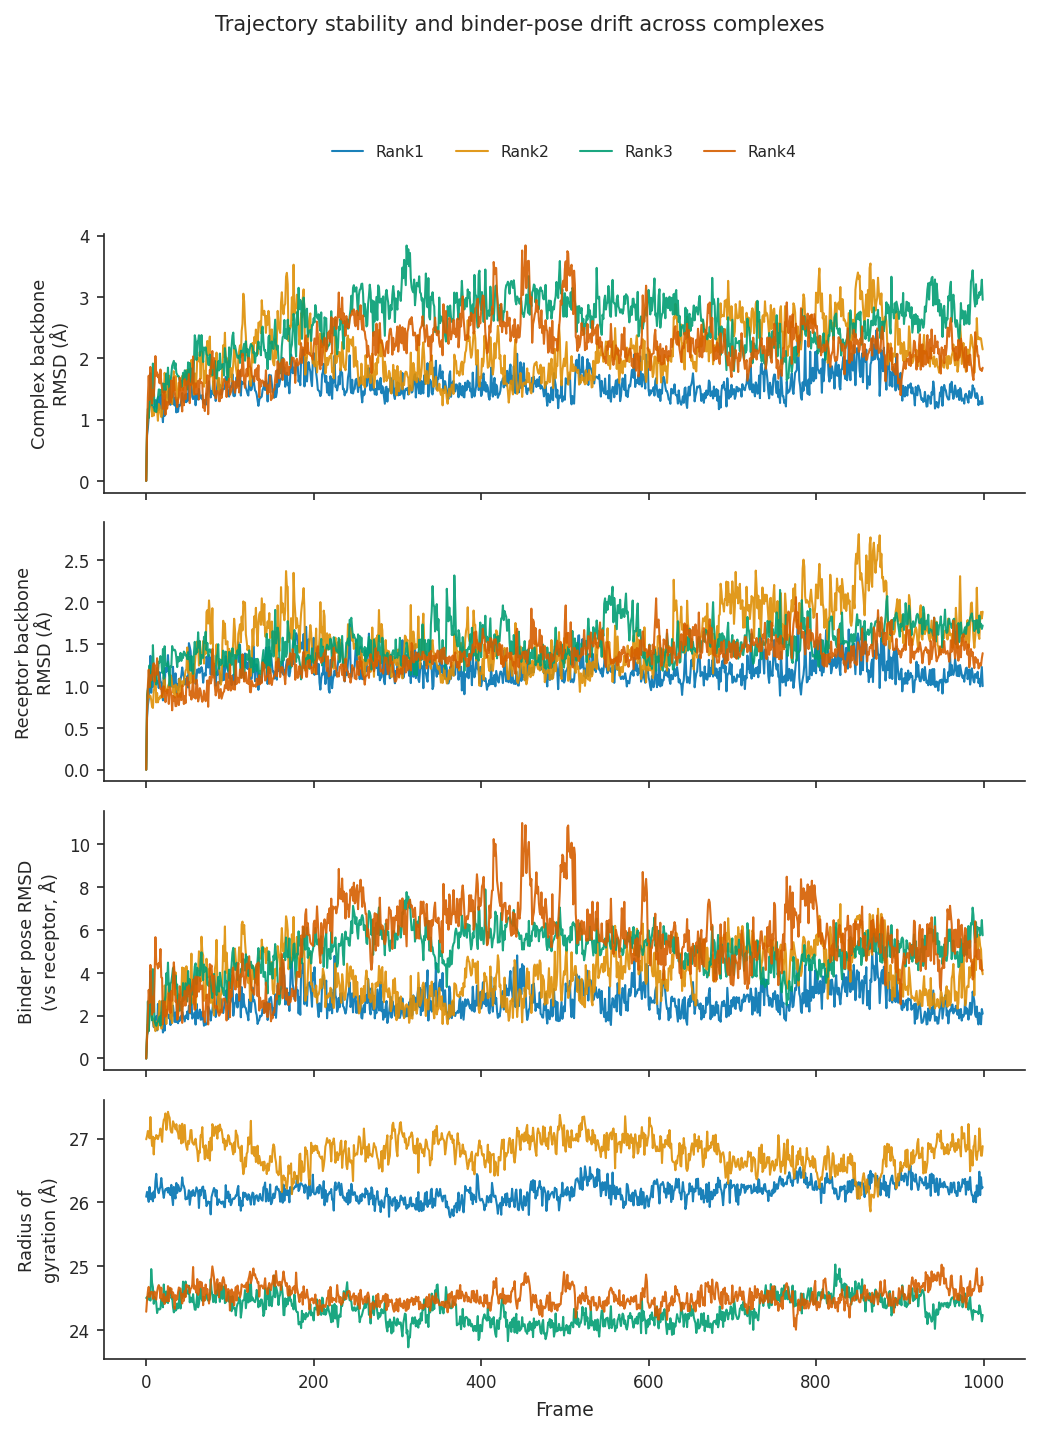

In [9]:
# @title 3.2 Time-series plot: RMSD (complex / receptor / interface) and Rg, all complexes

fig, axes = plt.subplots(4, 1, figsize=(7.0, 9.5), sharex=True)
panel_specs = [
    ("rmsd_complex", "Complex backbone\nRMSD (Å)"),
    ("rmsd_receptor", "Receptor backbone\nRMSD (Å)"),
    ("rmsd_interface", "Binder pose RMSD\n(vs receptor, Å)"),
    ("rg_complex", "Radius of\ngyration (Å)"),
]

for ax, (col, ylabel) in zip(axes, panel_specs):
    for name, df in metrics.items():
        ax.plot(df["frame"], df[col], lw=1.0, color=COLORS[name], label=name, alpha=0.9)
    ax.set_ylabel(ylabel, fontsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Frame")
axes[0].legend(ncol=len(COMPLEXES), loc="upper center", bbox_to_anchor=(0.5, 1.4),
               frameon=False)
fig.suptitle("Trajectory stability and binder-pose drift across complexes", y=1.0, fontsize=10)
fig.tight_layout(h_pad=1.2, rect=[0, 0, 1, 0.95])

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"01_timeseries_rmsd_rg.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()


## 4. Free Energy Landscapes (FEL)

We build 2D free energy landscapes from the conformational ensemble of each trajectory using
Gaussian kernel density estimation (KDE) of the sampled (CV<sub>1</sub>, CV<sub>2</sub>) space,
converted to free energy via

$$\Delta G(\mathrm{CV}_1, \mathrm{CV}_2) = -k_B T \ln P(\mathrm{CV}_1, \mathrm{CV}_2) + C$$

where $P$ is the KDE-estimated probability density and the landscape is shifted so the global
minimum is 0 kcal/mol. Two CV pairs are computed, both directly relevant to binder behavior:

- **FEL-1: RMSD<sub>complex</sub> vs R<sub>g</sub>** &mdash; classic stability/compactness landscape.
- **FEL-2: RMSD<sub>complex</sub> vs RMSD<sub>interface</sub>** &mdash; couples overall drift to binder-pose
  drift specifically, which is usually the more decision-relevant landscape for a designed binder
  (a deep, narrow single basin here means the binder found and kept one binding mode).

A PCA-based FEL (PC1 vs PC2 of receptor+binder backbone fluctuations) is also provided as a
supplementary, model-free alternative in Section 4.3.


In [10]:
# @title 4.1 FEL helper functions

KB_KCAL_MOL_K = 0.0019872041  # Boltzmann constant in kcal/(mol*K)

def free_energy_landscape(x, y, grid_points=150, bandwidth=None, temperature=300.0):
    """KDE-based 2D free energy landscape. Returns (xx, yy, G) with G in kcal/mol,
    shifted so the minimum is 0.
    """
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bandwidth)

    x_grid = np.linspace(x.min(), x.max(), grid_points)
    y_grid = np.linspace(y.min(), y.max(), grid_points)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])

    density = kde(grid_coords).reshape(xx.shape)
    density = np.clip(density, np.finfo(float).tiny, None)  # avoid log(0)

    kT = KB_KCAL_MOL_K * temperature
    G = -kT * np.log(density)
    G -= G.min()
    return xx, yy, G, kde


def assign_frame_free_energy(x, y, kde, temperature=300.0):
    """Free energy of each sampled (x, y) point itself (not the grid) — used to rank frames."""
    density_at_points = kde(np.vstack([x, y]))
    density_at_points = np.clip(density_at_points, np.finfo(float).tiny, None)
    kT = KB_KCAL_MOL_K * temperature
    G = -kT * np.log(density_at_points)
    G -= G.min()
    return G


def plot_fel(ax, xx, yy, G, scatter_x=None, scatter_y=None, scatter_color=None,
             xlabel="", ylabel="", title="", cbar_label="ΔG (kcal/mol)",
             top_points=None):
    levels = np.linspace(0, np.ceil(G.max()), 25)
    cf = ax.contourf(xx, yy, G, levels=levels, cmap="turbo")
    ax.contour(xx, yy, G, levels=levels, colors="k", linewidths=0.15, alpha=0.4)
    if scatter_x is not None:
        ax.scatter(scatter_x, scatter_y, s=1.5, c="white", alpha=0.15, linewidths=0)
    if top_points is not None:
        ax.scatter(top_points[:, 0], top_points[:, 1], marker="*", s=110,
                   c="white", edgecolors="black", linewidths=0.8, zorder=5,
                   label="Top-5 lowest ΔG frames")
        # 'best' lets matplotlib avoid the plotted markers automatically rather
        # than fixing a corner that may collide with a basin near the edge
        ax.legend(loc="best", frameon=True, fontsize=6.5, framealpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    return cf


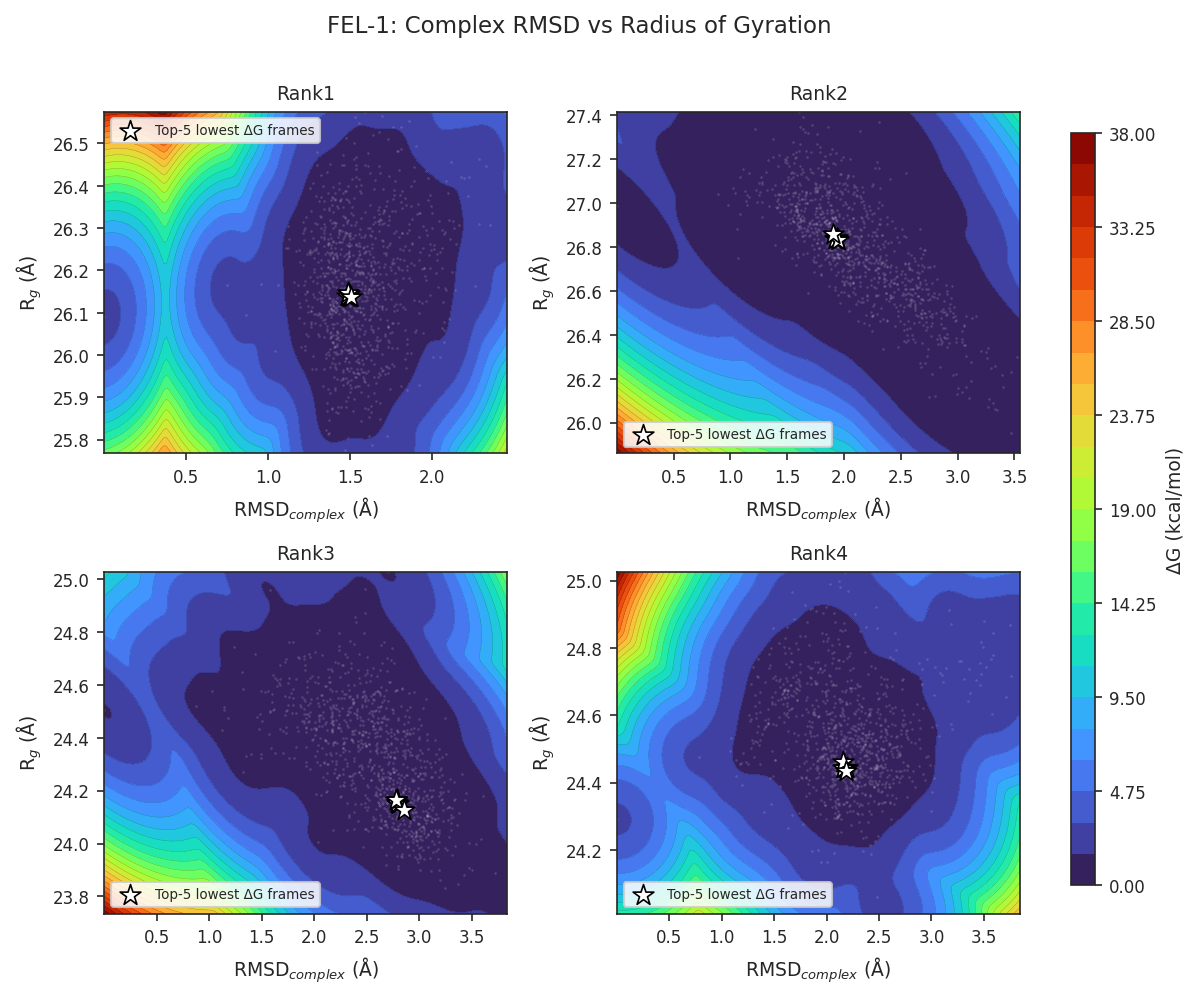

In [11]:
# @title 4.2 FEL-1: RMSD(complex) vs Rg, per complex + ranked frames

fel1_results = {}
top_frames_fel1 = {}

fig, axes = plt.subplots(2, 2, figsize=(7.8, 6.6))
axes = axes.ravel()

for ax, (name, df) in zip(axes, metrics.items()):
    x = df["rmsd_complex"].values
    y = df["rg_complex"].values
    xx, yy, G, kde = free_energy_landscape(x, y, grid_points=KDE_GRID_POINTS,
                                            bandwidth=KDE_BANDWIDTH,
                                            temperature=TEMPERATURE_K)
    frame_G = assign_frame_free_energy(x, y, kde, temperature=TEMPERATURE_K)
    df["dG_fel1_kcal_mol"] = frame_G

    order = np.argsort(frame_G)
    top_idx = order[:N_TOP_FRAMES]
    top_frames_fel1[name] = df.iloc[top_idx].copy()

    cf = plot_fel(ax, xx, yy, G, scatter_x=x, scatter_y=y,
                  xlabel="RMSD$_{complex}$ (Å)", ylabel="R$_g$ (Å)",
                  title=name, top_points=np.column_stack([x[top_idx], y[top_idx]]))
    fel1_results[name] = (xx, yy, G)

fig.tight_layout(rect=[0, 0, 0.90, 0.95])
cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.76])  # dedicated colorbar axis, outside the grid
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("ΔG (kcal/mol)")
fig.suptitle("FEL-1: Complex RMSD vs Radius of Gyration", y=1.0, fontsize=11)

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"02_FEL1_rmsd_vs_rg.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()


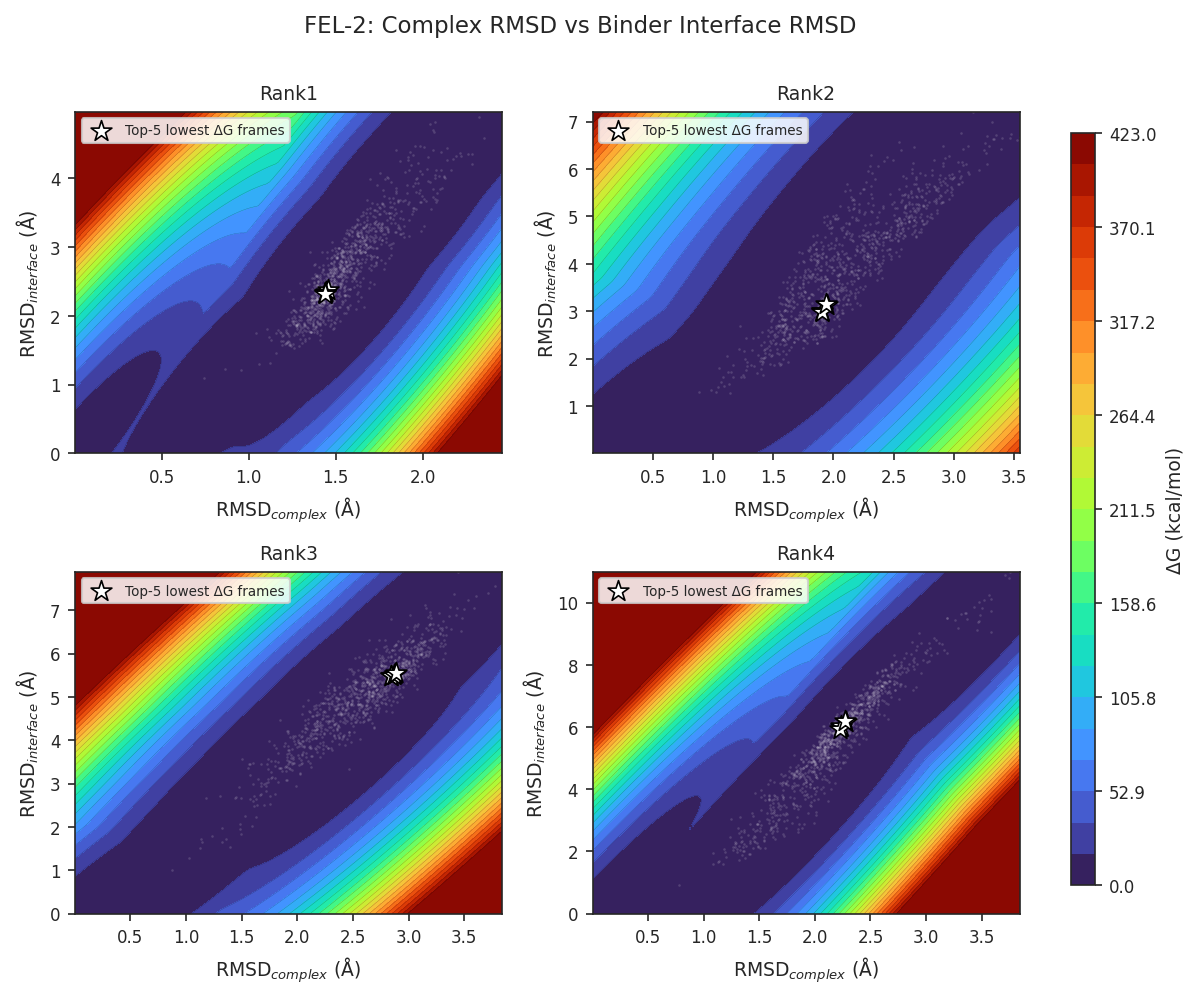

Primary ranking metric for downstream sections: dG_fel2_kcal_mol (binder-pose-aware free energy).


In [12]:
# @title 4.3 FEL-2: RMSD(complex) vs RMSD(interface), per complex + ranked frames
# This is usually the most informative landscape for a designed binder: a single
# deep, narrow basin indicates a binder that locks into one stable pose; multiple
# basins or a shallow/broad landscape indicate pose-hopping or partial dissociation.

fel2_results = {}
top_frames_fel2 = {}

fig, axes = plt.subplots(2, 2, figsize=(7.8, 6.6))
axes = axes.ravel()

for ax, (name, df) in zip(axes, metrics.items()):
    x = df["rmsd_complex"].values
    y = df["rmsd_interface"].values
    xx, yy, G, kde = free_energy_landscape(x, y, grid_points=KDE_GRID_POINTS,
                                            bandwidth=KDE_BANDWIDTH,
                                            temperature=TEMPERATURE_K)
    frame_G = assign_frame_free_energy(x, y, kde, temperature=TEMPERATURE_K)
    df["dG_fel2_kcal_mol"] = frame_G

    order = np.argsort(frame_G)
    top_idx = order[:N_TOP_FRAMES]
    top_frames_fel2[name] = df.iloc[top_idx].copy()

    cf = plot_fel(ax, xx, yy, G, scatter_x=x, scatter_y=y,
                  xlabel="RMSD$_{complex}$ (Å)", ylabel="RMSD$_{interface}$ (Å)",
                  title=name, top_points=np.column_stack([x[top_idx], y[top_idx]]))
    fel2_results[name] = (xx, yy, G)

fig.tight_layout(rect=[0, 0, 0.90, 0.95])
cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.76])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("ΔG (kcal/mol)")
fig.suptitle("FEL-2: Complex RMSD vs Binder Interface RMSD", y=1.0, fontsize=11)

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"03_FEL2_rmsd_vs_interface.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

print("Primary ranking metric for downstream sections: dG_fel2_kcal_mol "
      "(binder-pose-aware free energy).")


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


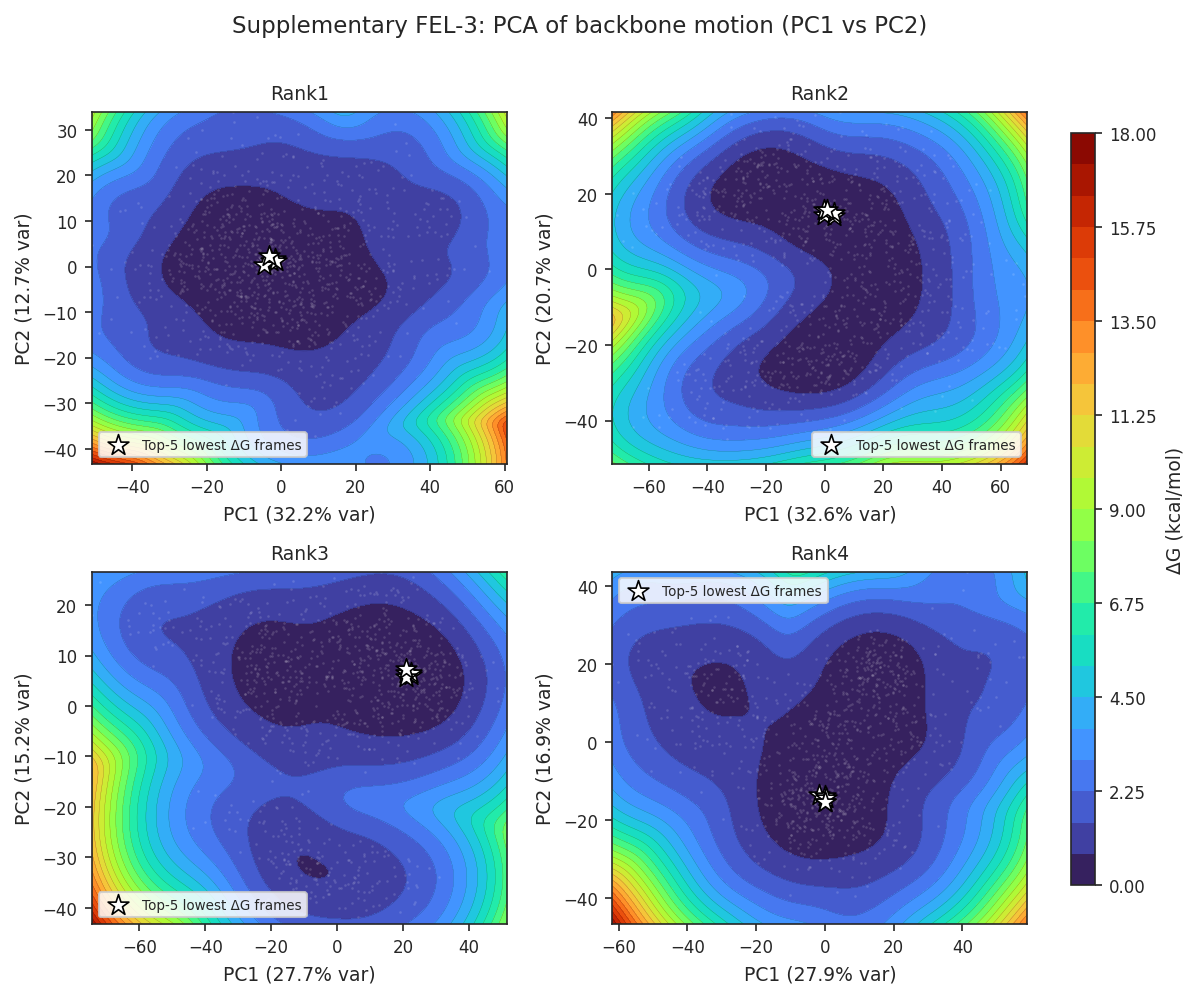

Cumulative variance explained by first 5 PCs, per complex:
  Rank1: ['32.2%', '44.8%', '53.7%', '58.5%', '62.3%']
  Rank2: ['32.6%', '53.3%', '60.9%', '66.1%', '69.4%']
  Rank3: ['27.7%', '42.9%', '52.6%', '60.3%', '67.1%']
  Rank4: ['27.9%', '44.8%', '53.2%', '59.3%', '63.6%']


In [13]:
# @title 4.4 Supplementary FEL-3: PCA (PC1 vs PC2) on backbone fluctuations
# Model-free alternative to RMSD/Rg — captures the dominant collective motions
# directly, without assuming RMSD/Rg are the most informative coordinates.

fel3_results = {}
top_frames_fel3 = {}
pca_variance_explained = {}

fig, axes = plt.subplots(2, 2, figsize=(7.8, 6.6))
axes = axes.ravel()

for ax, (name, paths) in zip(axes, COMPLEXES.items()):
    u = mda.Universe(paths["pdb"], paths["dcd"])
    bb_sel = f"backbone and ({RECEPTOR_SEL} or {BINDER_SEL})"

    aligner = align.AlignTraj(u, u, select=bb_sel, in_memory=True).run()

    pc = pca.PCA(u, select=bb_sel, align=False, mean=None).run()
    cum_var = pc.results.cumulated_variance
    n_pcs_for_90 = np.searchsorted(cum_var, 0.90) + 1
    transformed = pc.transform(u.select_atoms(bb_sel), n_components=2)

    pca_variance_explained[name] = cum_var[:5].tolist()

    x = transformed[:, 0]
    y = transformed[:, 1]
    xx, yy, G, kde = free_energy_landscape(x, y, grid_points=KDE_GRID_POINTS,
                                            bandwidth=KDE_BANDWIDTH,
                                            temperature=TEMPERATURE_K)
    frame_G = assign_frame_free_energy(x, y, kde, temperature=TEMPERATURE_K)

    df_pca = pd.DataFrame({"frame": np.arange(len(x)), "PC1": x, "PC2": y,
                            "dG_fel3_kcal_mol": frame_G})
    order = np.argsort(frame_G)
    top_frames_fel3[name] = df_pca.iloc[order[:N_TOP_FRAMES]].copy()

    cf = plot_fel(ax, xx, yy, G, scatter_x=x, scatter_y=y,
                  xlabel=f"PC1 ({cum_var[0]*100:.1f}% var)",
                  ylabel=f"PC2 ({(cum_var[1]-cum_var[0])*100:.1f}% var)",
                  title=name, top_points=np.column_stack([x[order[:N_TOP_FRAMES]],
                                                            y[order[:N_TOP_FRAMES]]]))
    fel3_results[name] = (xx, yy, G)
    del u

fig.tight_layout(rect=[0, 0, 0.90, 0.95])
cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.76])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("ΔG (kcal/mol)")
fig.suptitle("Supplementary FEL-3: PCA of backbone motion (PC1 vs PC2)", y=1.0, fontsize=11)

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"04_FEL3_pca.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

print("Cumulative variance explained by first 5 PCs, per complex:")
for name, var in pca_variance_explained.items():
    print(f"  {name}: {['%.1f%%' % (v*100) for v in var]}")


## 5. Per-residue flexibility (RMSF) and interface contact analysis

- **RMSF** (root-mean-square fluctuation) per residue, computed after superposing each
  trajectory on the **receptor** backbone (so binder RMSF reflects real positional
  fluctuation relative to the receptor, not just whole-complex tumbling). Interface
  residues (any residue with a heavy atom within `INTERFACE_CUTOFF_A` of the partner chain
  in the first frame) are highlighted.
- **Interface contacts**: per-frame count of heavy-atom contact pairs (receptor&ndash;binder)
  within `INTERFACE_CUTOFF_A`, used as a simple, assumption-light proxy for interface
  burial/contact-area stability over the trajectory.
- **Hydrogen bonds**: per-frame count of receptor&ndash;binder hydrogen bonds, a specific and
  commonly reported metric of interface polar contact stability.


In [14]:
# @title 5.1 RMSF per residue (receptor-superposed) with interface residues flagged

def compute_rmsf_and_interface(pdb_path, dcd_path, receptor_sel, binder_sel,
                                interface_cutoff=4.5, stride=1):
    u = mda.Universe(pdb_path, dcd_path)
    receptor_bb_sel = f"backbone and ({receptor_sel})"

    # Superpose every frame on the receptor backbone (rigid scaffold reference)
    align.AlignTraj(u, u, select=receptor_bb_sel, in_memory=True).run(step=stride)

    ca_sel = f"name CA and ({receptor_sel} or {binder_sel})"
    ca_atoms = u.select_atoms(ca_sel)
    rmsf_vals = rms.RMSF(ca_atoms, verbose=False).run(step=stride).results.rmsf

    # interface residues, defined from frame 0 heavy-atom contacts
    u.trajectory[0]
    rec_heavy = u.select_atoms(f"not name H* and ({receptor_sel})")
    bind_heavy = u.select_atoms(f"not name H* and ({binder_sel})")
    dist = distance_array(rec_heavy.positions, bind_heavy.positions)
    contact_mask = dist < interface_cutoff
    rec_interface_resids = set(rec_heavy.resids[contact_mask.any(axis=1)])
    bind_interface_resids = set(bind_heavy.resids[contact_mask.any(axis=0)])
    interface_resids = rec_interface_resids | bind_interface_resids

    rmsf_df = pd.DataFrame({
        "resid": ca_atoms.resids,
        "resname": ca_atoms.resnames,
        "rmsf": rmsf_vals,
        "is_interface": [r in interface_resids for r in ca_atoms.resids],
        "region": ["receptor" if r <= RECEPTOR_LAST_RESID else "binder" for r in ca_atoms.resids],
    })
    return rmsf_df, interface_resids


rmsf_data = {}
interface_residue_sets = {}
for name, paths in COMPLEXES.items():
    print(f"Computing RMSF / interface for {name} ...")
    rmsf_df, iface = compute_rmsf_and_interface(
        paths["pdb"], paths["dcd"], RECEPTOR_SEL, BINDER_SEL,
        interface_cutoff=INTERFACE_CUTOFF_A, stride=STRIDE,
    )
    rmsf_data[name] = rmsf_df
    interface_residue_sets[name] = iface
    rmsf_df.to_csv(os.path.join(DATA_DIR, f"{name}_rmsf.csv"), index=False)

print("RMSF tables saved to", DATA_DIR)


Computing RMSF / interface for Rank1 ...
Computing RMSF / interface for Rank2 ...
Computing RMSF / interface for Rank3 ...
Computing RMSF / interface for Rank4 ...
RMSF tables saved to /content/outputs/data


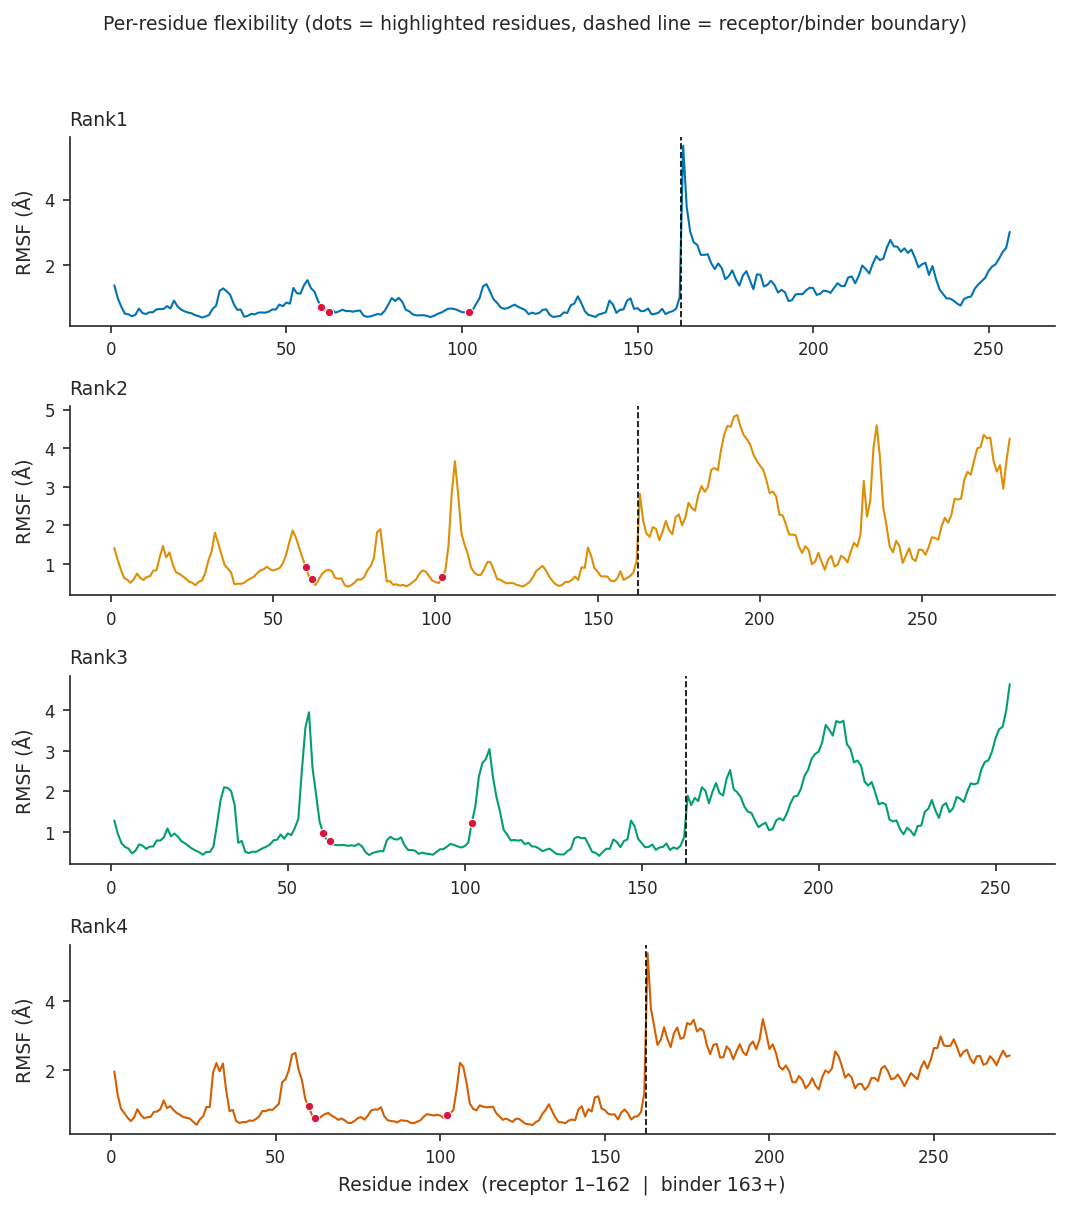

In [15]:
# @title 5.2 Plot: per-residue RMSF, all complexes, specific residues highlighted

fig, axes = plt.subplots(len(COMPLEXES), 1, figsize=(7.2, 2.0 * len(COMPLEXES)), sharex=False)
if len(COMPLEXES) == 1:
    axes = [axes]

# Define the specific residues to denote (assumes df["resid"] uses integer indexing)
highlight_resids = [60, 62, 102]

for ax, (name, df) in zip(axes, rmsf_data.items()):
    # Plot the main RMSF line
    ax.plot(df["resid"], df["rmsf"], color=COLORS[name], lw=1.0)

    # Overlay small circles for H60, H62, H102
    highlight_df = df[df["resid"].isin(highlight_resids)]
    if not highlight_df.empty:
        ax.plot(
            highlight_df["resid"],
            highlight_df["rmsf"],
            "o",                 # Circle marker
            color="crimson",     # Contrasting color to make them pop
            ms=4,                # Small marker size
            mec="white",         # White edge color for crisp contrast
            mew=0.5,             # Thin edge width
            zorder=5             # Ensures dots sit on top of the line
        )

    # REMOVED: Loop for shading interface residues (ax.axvspan) has been taken out.

    # Keep the receptor/binder boundary line
    ax.axvline(RECEPTOR_LAST_RESID + 0.5, color="black", ls="--", lw=0.8)
    ax.set_ylabel("RMSF (Å)")
    ax.set_title(name, fontsize=9, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Residue index  (receptor 1–{0}  |  binder {1}+)".format(
    RECEPTOR_LAST_RESID, RECEPTOR_LAST_RESID + 1))

# Updated title text to reflect the removal of the gray shading
fig.suptitle("Per-residue flexibility (dots = highlighted residues, dashed line = receptor/binder boundary)",
             fontsize=9, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"05_RMSF_per_residue.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

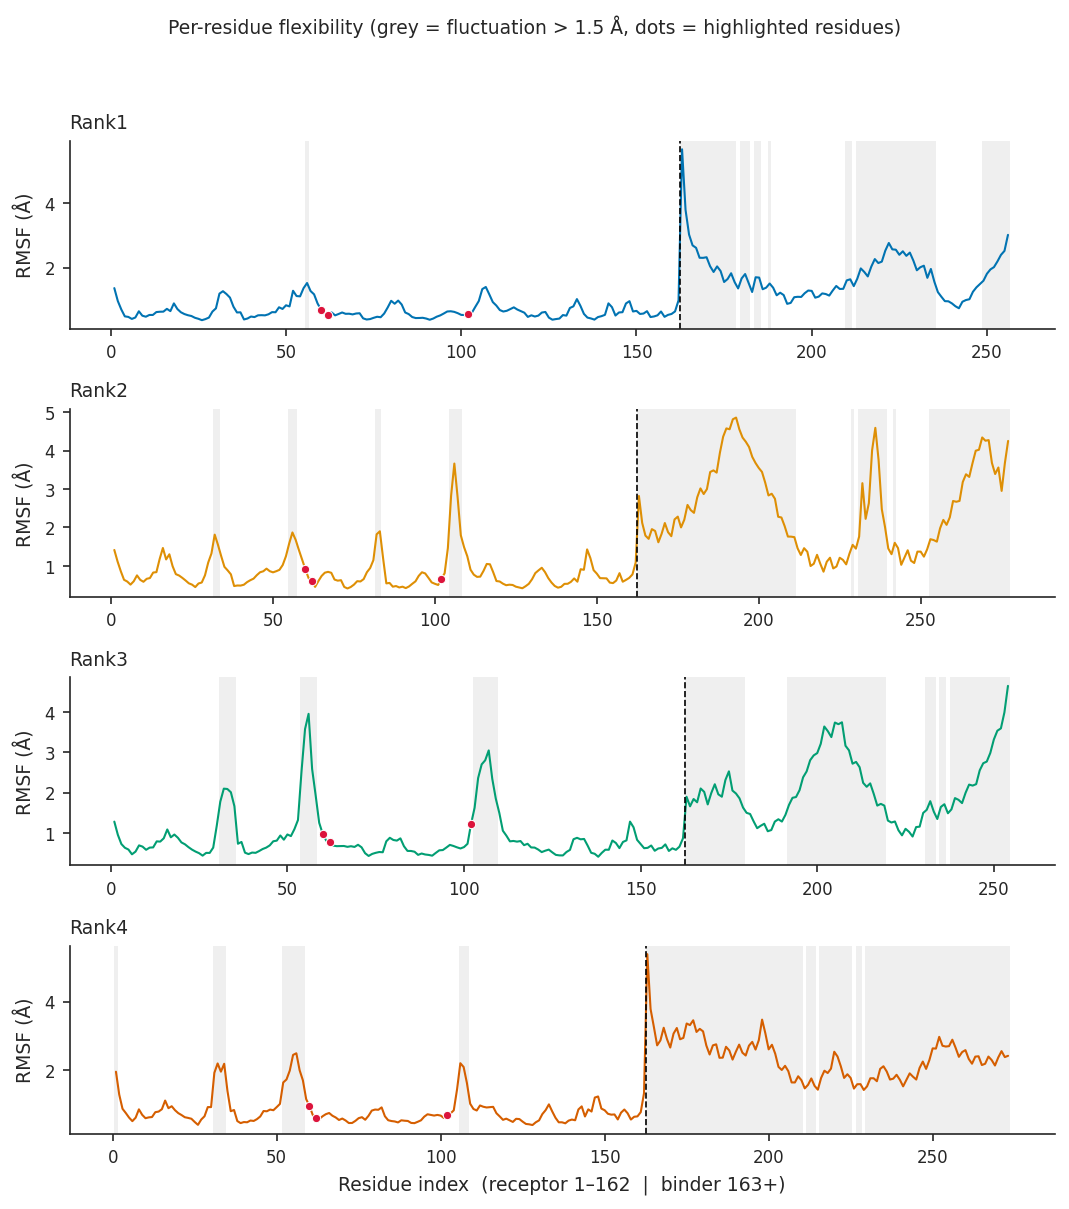

In [16]:
# @title 5.2 Plot: per-residue RMSF, all complexes, peaks > 1.5 Å shaded

fig, axes = plt.subplots(len(COMPLEXES), 1, figsize=(7.2, 2.0 * len(COMPLEXES)), sharex=False)
if len(COMPLEXES) == 1:
    axes = [axes]

# Define the specific residues to denote (assumes df["resid"] uses integer indexing)
highlight_resids = [60, 62, 102]

for ax, (name, df) in zip(axes, rmsf_data.items()):
    # Plot the main RMSF line
    ax.plot(df["resid"], df["rmsf"], color=COLORS[name], lw=1.0)

    # Overlay small circles for H60, H62, H102
    highlight_df = df[df["resid"].isin(highlight_resids)]
    if not highlight_df.empty:
        ax.plot(
            highlight_df["resid"],
            highlight_df["rmsf"],
            "o",                 # Circle marker
            color="crimson",     # Contrasting color to make them pop
            ms=4,                # Small marker size
            mec="white",         # White edge color for crisp contrast
            mew=0.5,             # Thin edge width
            zorder=5             # Ensures dots sit on top of the line
        )

    # --- NEW: Shade only regions where RMSF fluctuation > 1.5 ---
    high_flex_resids = df.loc[df["rmsf"] > 1.5, "resid"].tolist()
    for r in high_flex_resids:
        ax.axvspan(r - 0.5, r + 0.5, color="grey", alpha=0.12, lw=0, zorder=0)
    # ------------------------------------------------------------

    # Keep the receptor/binder boundary line
    ax.axvline(RECEPTOR_LAST_RESID + 0.5, color="black", ls="--", lw=0.8)
    ax.set_ylabel("RMSF (Å)")
    ax.set_title(name, fontsize=9, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Residue index  (receptor 1–{0}  |  binder {1}+)".format(
    RECEPTOR_LAST_RESID, RECEPTOR_LAST_RESID + 1))

# Updated title text to reflect the conditional 1.5 Å threshold shading
fig.suptitle("Per-residue flexibility (grey = fluctuation > 1.5 Å, dots = highlighted residues)",
             fontsize=9, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"05_RMSF_per_residue.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

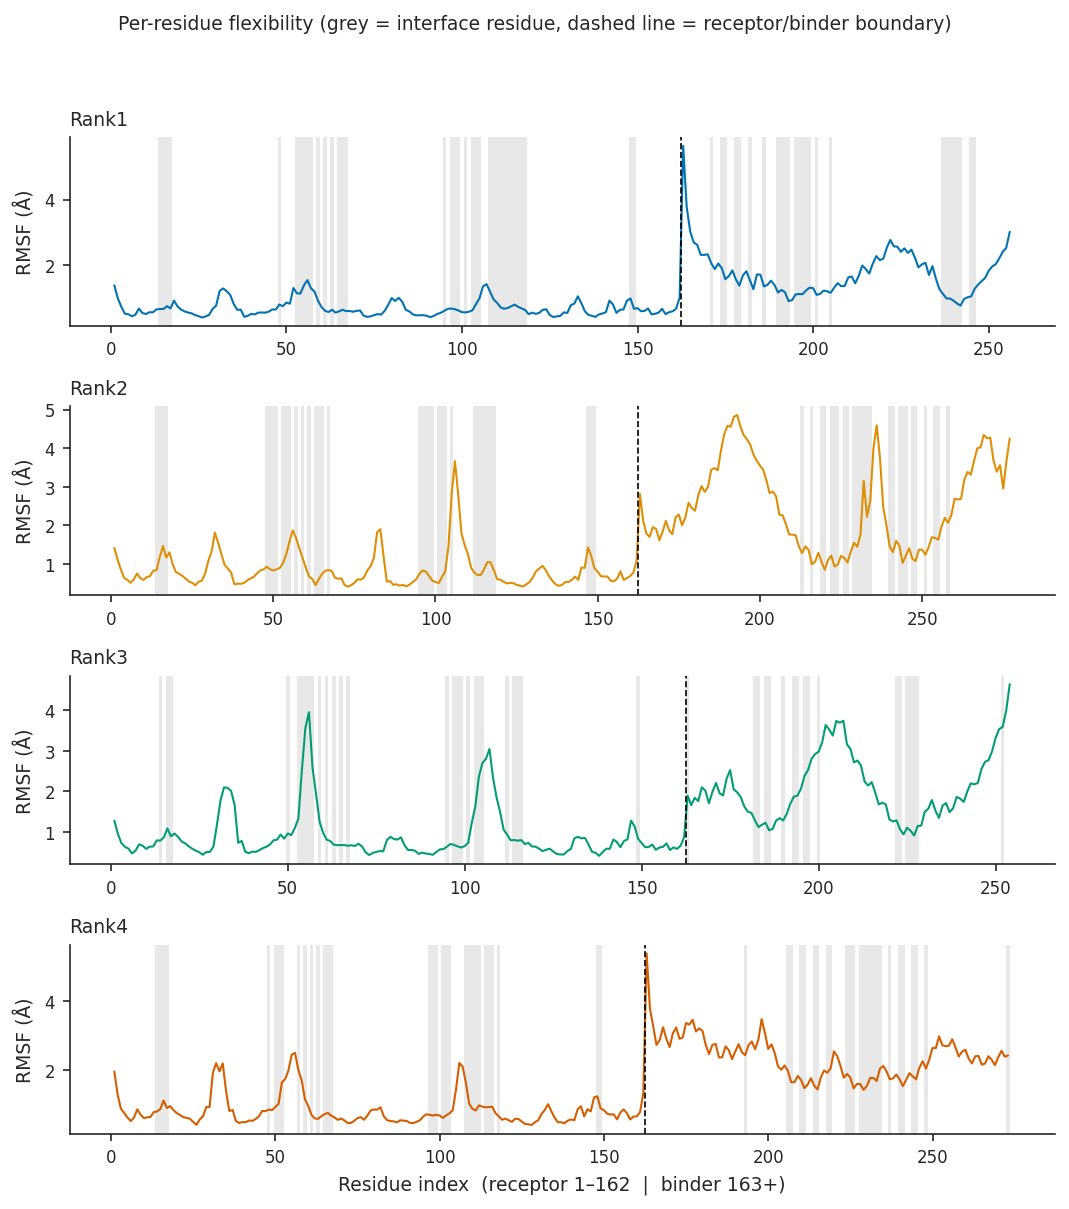

In [17]:
# @title 5.2 Plot: per-residue RMSF, all complexes, interface residues shaded

fig, axes = plt.subplots(len(COMPLEXES), 1, figsize=(7.2, 2.0 * len(COMPLEXES)), sharex=False)
if len(COMPLEXES) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, rmsf_data.items()):
    ax.plot(df["resid"], df["rmsf"], color=COLORS[name], lw=1.0)
    # shade interface residues
    iface_resids = sorted(df.loc[df["is_interface"], "resid"].tolist())
    for r in iface_resids:
        ax.axvspan(r - 0.5, r + 0.5, color="grey", alpha=0.18, lw=0)
    ax.axvline(RECEPTOR_LAST_RESID + 0.5, color="black", ls="--", lw=0.8)
    ax.set_ylabel("RMSF (Å)")
    ax.set_title(name, fontsize=9, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Residue index  (receptor 1–{0}  |  binder {1}+)".format(
    RECEPTOR_LAST_RESID, RECEPTOR_LAST_RESID + 1))
fig.suptitle("Per-residue flexibility (grey = interface residue, dashed line = receptor/binder boundary)",
             fontsize=9, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"05_RMSF_per_residue.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()


In [18]:
# @title 5.3 Interface heavy-atom contacts and H-bonds per frame

def compute_interface_dynamics(pdb_path, dcd_path, receptor_sel, binder_sel,
                                contact_cutoff=4.5, stride=1):
    u = mda.Universe(pdb_path, dcd_path)
    rec_heavy_sel = f"not name H* and ({receptor_sel})"
    bind_heavy_sel = f"not name H* and ({binder_sel})"
    rec_heavy = u.select_atoms(rec_heavy_sel)
    bind_heavy = u.select_atoms(bind_heavy_sel)

    contacts = []
    for ts in u.trajectory[::stride]:
        dist = distance_array(rec_heavy.positions, bind_heavy.positions)
        n_contacts = int(np.sum(dist < contact_cutoff))
        contacts.append(n_contacts)

    contacts_df = pd.DataFrame({
        "frame": np.arange(0, u.trajectory.n_frames, stride),
        "n_interface_contacts": contacts,
    })

    # Hydrogen bonds between receptor and binder, identified by DISTANCE rather than
    # topology bonds: plain OpenMM-written PDBs typically have no CONECT records, so
    # relying on bonded_atoms (the default when donors_sel=None) fails. Instead we give
    # explicit donor/hydrogen/acceptor selections and let d_h_cutoff pair them by distance.
    n_hydrogens = len(u.select_atoms("name H*"))
    if n_hydrogens == 0:
        print("  [warning] No hydrogen atoms found in this topology (name H*) - "
              "H-bond analysis requires explicit hydrogens. Filling n_interface_hbonds "
              "with NaN. Contact-count metric is unaffected.")
        contacts_df["n_interface_hbonds"] = np.nan
        return contacts_df

    try:
        donor_heavy_sel = f"({receptor_sel} or {binder_sel}) and (name N* or name O* or name S*) and not name H*"
        hydrogens_sel = f"({receptor_sel} or {binder_sel}) and name H*"
        acceptor_sel = f"({receptor_sel} or {binder_sel}) and (name O* or name N*) and not name H*"

        hbonds = HydrogenBondAnalysis(
            universe=u,
            donors_sel=donor_heavy_sel,
            hydrogens_sel=hydrogens_sel,
            acceptors_sel=acceptor_sel,
            d_h_cutoff=1.2,       # max donor-hydrogen distance (Å) to pair them
            d_a_cutoff=3.5, d_h_a_angle_cutoff=150, update_selections=False,
        )
        hbonds.run(step=stride, verbose=False)
        hb_results = hbonds.results.hbonds  # columns: frame, donor_ix, hyd_ix, acceptor_ix, dist, angle
        rec_idx = set(u.select_atoms(receptor_sel).indices)
        bind_idx = set(u.select_atoms(binder_sel).indices)

        hb_count_per_frame = {}
        for row in hb_results:
            frame_i, donor_ix, hyd_ix, acc_ix = int(row[0]), int(row[1]), int(row[2]), int(row[3])
            donor_in_rec = donor_ix in rec_idx
            acc_in_rec = acc_ix in rec_idx
            donor_in_bind = donor_ix in bind_idx
            acc_in_bind = acc_ix in bind_idx
            is_interface_hb = (donor_in_rec and acc_in_bind) or (donor_in_bind and acc_in_rec)
            if is_interface_hb:
                hb_count_per_frame[frame_i] = hb_count_per_frame.get(frame_i, 0) + 1

        contacts_df["n_interface_hbonds"] = contacts_df["frame"].map(
            lambda f: hb_count_per_frame.get(f, 0))
    except Exception as e:
        print(f"  [warning] H-bond analysis failed ({e}); filling with NaN. "
              f"Contact-count metric is unaffected.")
        contacts_df["n_interface_hbonds"] = np.nan

    return contacts_df


interface_dynamics = {}
for name, paths in COMPLEXES.items():
    print(f"Computing interface contacts / H-bonds for {name} ...")
    df_contacts = compute_interface_dynamics(
        paths["pdb"], paths["dcd"], RECEPTOR_SEL, BINDER_SEL,
        contact_cutoff=INTERFACE_CUTOFF_A, stride=STRIDE,
    )
    interface_dynamics[name] = df_contacts
    df_contacts.to_csv(os.path.join(DATA_DIR, f"{name}_interface_dynamics.csv"), index=False)

print("Interface contact/H-bond tables saved to", DATA_DIR)

Computing interface contacts / H-bonds for Rank1 ...
Computing interface contacts / H-bonds for Rank2 ...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Computing interface contacts / H-bonds for Rank3 ...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Computing interface contacts / H-bonds for Rank4 ...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Interface contact/H-bond tables saved to /content/outputs/data


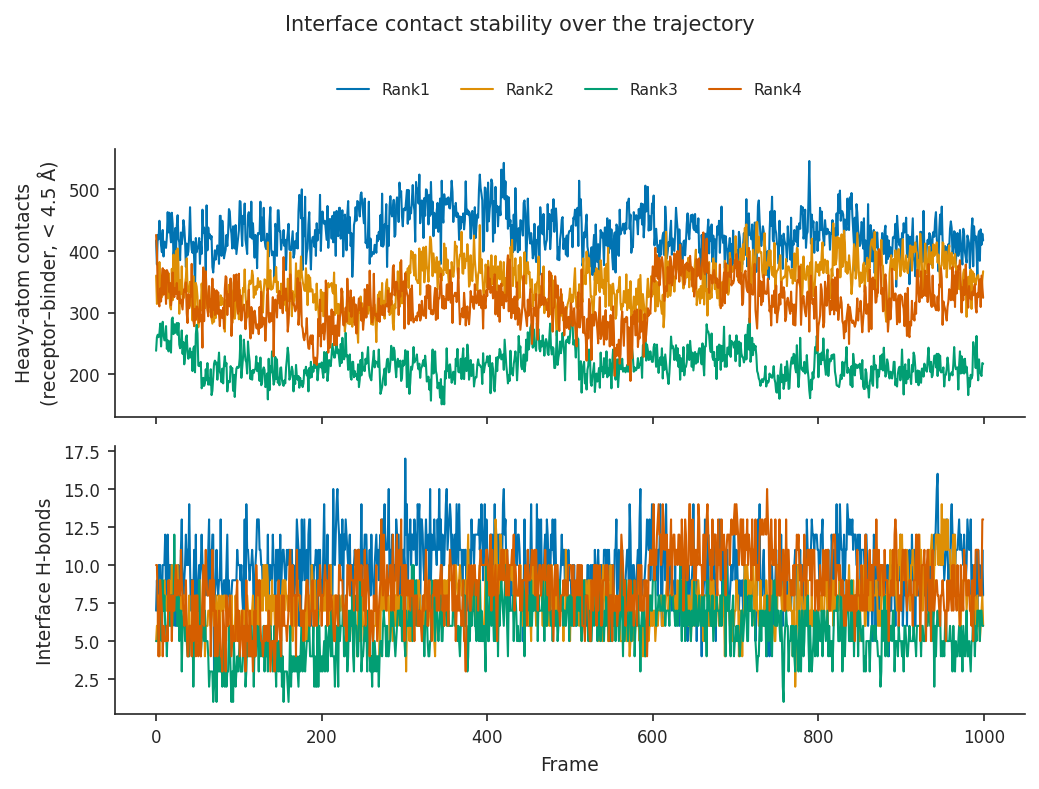

In [19]:
# @title 5.4 Plot: interface contacts and H-bonds over time

fig, axes = plt.subplots(2, 1, figsize=(7.0, 5.2), sharex=True)

for name, df in interface_dynamics.items():
    axes[0].plot(df["frame"], df["n_interface_contacts"], color=COLORS[name], lw=1.0, label=name)
    axes[1].plot(df["frame"], df["n_interface_hbonds"], color=COLORS[name], lw=1.0, label=name)

axes[0].set_ylabel("Heavy-atom contacts\n(receptor–binder, < {:.1f} Å)".format(INTERFACE_CUTOFF_A))
axes[1].set_ylabel("Interface H-bonds")
axes[1].set_xlabel("Frame")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(ncol=len(COMPLEXES), loc="upper center", bbox_to_anchor=(0.5, 1.3), frameon=False)
fig.suptitle("Interface contact stability over the trajectory", y=1.0, fontsize=10)
fig.tight_layout()

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"06_interface_contacts_hbonds.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

## 6. Extracting the top-5 lowest free-energy frames

Using the **FEL-2 (RMSD<sub>complex</sub> vs RMSD<sub>interface</sub>)** landscape as the primary
ranking &mdash; since it is the most binder-pose-aware metric &mdash; we extract the five
lowest-&Delta;G frames per complex and write each out as a standalone PDB. These are good
candidates for: representative-structure figures, MM/GBSA or other rescoring, and further
inspection of the most probable bound conformations.


In [20]:
# @title 6.1 Write top-5 lowest-ΔG frames to PDB, per complex

top_frames_summary_rows = []

for name, paths in COMPLEXES.items():
    u = mda.Universe(paths["pdb"], paths["dcd"])
    df_top = top_frames_fel2[name].sort_values("dG_fel2_kcal_mol").reset_index(drop=True)

    for rank, row in df_top.iterrows():
        frame_idx = int(row["frame"])
        u.trajectory[frame_idx]
        out_path = os.path.join(FRAME_DIR, f"{name}_lowestG_rank{rank+1}_frame{frame_idx}.pdb")
        u.atoms.write(out_path)
        top_frames_summary_rows.append({
            "complex": name,
            "energy_rank": rank + 1,
            "frame": frame_idx,
            "dG_fel2_kcal_mol": row["dG_fel2_kcal_mol"],
            "rmsd_complex_A": row["rmsd_complex"],
            "rmsd_interface_A": row["rmsd_interface"],
            "rg_A": row["rg_complex"],
            "output_pdb": out_path,
        })
    del u

top_frames_summary = pd.DataFrame(top_frames_summary_rows)
top_frames_summary.to_csv(os.path.join(DATA_DIR, "top5_lowest_energy_frames_ALL_complexes.csv"),
                           index=False)
print(f"Wrote {len(top_frames_summary)} lowest-ΔG frame PDBs to {FRAME_DIR}")
display(top_frames_summary)


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Wrote 20 lowest-ΔG frame PDBs to /content/outputs/lowest_energy_frames


,complex,energy_rank,frame,dG_fel2_kcal_mol,rmsd_complex_A,rmsd_interface_A,rg_A,output_pdb
0,Rank1,1,938,0.000000,1.447333,2.345924,26.450232,/content/outputs/lowest_energy_frames/Rank1_lo...
1,Rank1,2,905,0.000018,1.455538,2.380590,26.327484,/content/outputs/lowest_energy_frames/Rank1_lo...
2,Rank1,3,948,0.000040,1.441310,2.331580,26.367923,/content/outputs/lowest_energy_frames/Rank1_lo...
3,Rank1,4,454,0.000178,1.441346,2.328166,26.046445,/content/outputs/lowest_energy_frames/Rank1_lo...
4,Rank1,5,807,0.000646,1.436805,2.317329,26.295047,/content/outputs/lowest_energy_frames/Rank1_lo...
5,Rank2,1,955,0.000000,1.946794,3.137417,26.767462,/content/outputs/lowest_energy_frames/Rank2_lo...
6,Rank2,2,376,0.002039,1.905617,3.005853,26.799255,/content/outputs/lowest_energy_frames/Rank2_lo...
7,Rank2,3,152,0.002210,1.901059,3.008601,26.908698,/content/outputs/lowest_energy_frames/Rank2_lo...
8,Rank2,4,206,0.003081,1.903311,2.992278,26.794593,/content/outputs/lowest_energy_frames/Rank2_lo...
9,Rank2,5,640,0.003095,1.934859,3.153718,26.892639,/content/outputs/lowest_energy_frames/Rank2_lo...


## 7. Which complex behaves best? Cross-complex ranking summary

We combine several independent lines of evidence into one ranking table, rather than relying
on a single number:

| Metric | What it measures | Lower/Higher is "better" |
|---|---|---|
| Mean RMSD<sub>complex</sub> | Overall structural stability | Lower |
| Mean RMSD<sub>interface</sub> | Binder pose stability relative to receptor | Lower |
| Std. dev. of RMSD<sub>interface</sub> | Consistency of binder pose (avoids rewarding a stable-but-wrong pose) | Lower |
| FEL-2 basin depth (max &Delta;G sampled) | How energetically well-defined the dominant pose is | Higher (deeper basin) |
| Mean interface heavy-atom contacts | Degree of interface burial | Higher |
| Mean interface H-bonds | Polar interface stability | Higher |
| Global minimum dG_fel2 frame's RMSD<sub>interface</sub> | How close the most probable state is to the starting docked pose | Lower |

Each metric is min-max normalized across the four complexes and combined into a single
**composite kinetics score** (0&ndash;1, higher = better) with equal weighting by default &mdash;
edit `METRIC_WEIGHTS` in the cell below if you want to emphasize a particular criterion for
your manuscript's narrative (e.g. weighting interface RMSD more heavily if pose retention is
your primary design objective).


In [21]:
# @title 7.1 Build the ranking table

ranking_rows = []
for name in COMPLEXES:
    df = metrics[name]
    contacts_df = interface_dynamics[name]
    fel2_xx, fel2_yy, fel2_G = fel2_results[name]

    global_min_frame = top_frames_fel2[name].sort_values("dG_fel2_kcal_mol").iloc[0]

    ranking_rows.append({
        "complex": name,
        "mean_rmsd_complex": df["rmsd_complex"].mean(),
        "mean_rmsd_interface": df["rmsd_interface"].mean(),
        "std_rmsd_interface": df["rmsd_interface"].std(),
        "fel2_basin_depth_kcal_mol": fel2_G.max(),  # depth of sampled landscape (higher = more energetically discriminating)
        "mean_interface_contacts": contacts_df["n_interface_contacts"].mean(),
        "mean_interface_hbonds": contacts_df["n_interface_hbonds"].mean(),
        "global_min_rmsd_interface_A": global_min_frame["rmsd_interface"],
    })

ranking_df = pd.DataFrame(ranking_rows).set_index("complex")

# --- normalize each column to [0, 1] in the "better" direction, then combine ---
METRIC_WEIGHTS = {
    "mean_rmsd_complex": 1.0,              # lower is better
    "mean_rmsd_interface": 1.5,            # lower is better (weighted up: pose retention emphasis)
    "std_rmsd_interface": 1.0,             # lower is better
    "fel2_basin_depth_kcal_mol": 1.0,      # higher is better
    "mean_interface_contacts": 1.0,        # higher is better
    "mean_interface_hbonds": 0.5,          # higher is better
    "global_min_rmsd_interface_A": 1.0,    # lower is better
}
LOWER_IS_BETTER = {"mean_rmsd_complex", "mean_rmsd_interface", "std_rmsd_interface",
                    "global_min_rmsd_interface_A"}

norm_df = pd.DataFrame(index=ranking_df.index)
for col in ranking_df.columns:
    vals = ranking_df[col]
    if vals.isna().all():
        # entire metric unavailable (e.g. H-bond detection failed for all complexes) -
        # leave as NaN so it can be cleanly excluded from the composite score below,
        # rather than silently averaging in as a contribution of 0
        norm_df[col] = np.nan
        continue
    rng = vals.max() - vals.min()
    if rng == 0 or pd.isna(rng):
        norm = pd.Series(1.0, index=vals.index)
    else:
        norm = (vals - vals.min()) / rng
    if col in LOWER_IS_BETTER:
        norm = 1 - norm
    norm_df[col] = norm

weights = pd.Series(METRIC_WEIGHTS)
# Per-complex renormalization: if a metric is NaN, exclude it from BOTH the
# numerator and that complex's effective weight total, rather than treating
# a missing metric as a score of 0 (which would unfairly penalize every
# complex equally and silently distort the ranking).
weighted_vals = norm_df[weights.index] * weights
effective_weight_total = (~norm_df[weights.index].isna()).astype(float) @ weights
composite_score = weighted_vals.sum(axis=1, skipna=True) / effective_weight_total

dropped_metrics = [c for c in weights.index if norm_df[c].isna().all()]
if dropped_metrics:
    print(f"Note: excluded from composite score (no data): {dropped_metrics}")

ranking_df["composite_kinetics_score"] = composite_score
ranking_df = ranking_df.sort_values("composite_kinetics_score", ascending=False)

ranking_df.to_csv(os.path.join(DATA_DIR, "cross_complex_ranking_summary.csv"))
print("Composite ranking (higher score = better simulated behavior):\n")
display(ranking_df.round(3))

best_complex = ranking_df.index[0]
print(f"\n>>> Best-behaved complex by composite kinetics score: {best_complex}")


Composite ranking (higher score = better simulated behavior):



,mean_rmsd_complex,mean_rmsd_interface,std_rmsd_interface,fel2_basin_depth_kcal_mol,mean_interface_contacts,mean_interface_hbonds,global_min_rmsd_interface_A,composite_kinetics_score
complex,,,,,,,,
Rank1,1.555,2.684,0.673,422.915,430.818,9.885,2.346,1.000
Rank2,2.102,3.928,1.192,421.923,350.272,7.536,3.137,0.489
Rank4,2.181,5.526,1.708,422.288,316.365,8.600,6.014,0.223
Rank3,2.564,4.993,1.036,422.276,216.226,5.771,5.476,0.205



>>> Best-behaved complex by composite kinetics score: Rank1


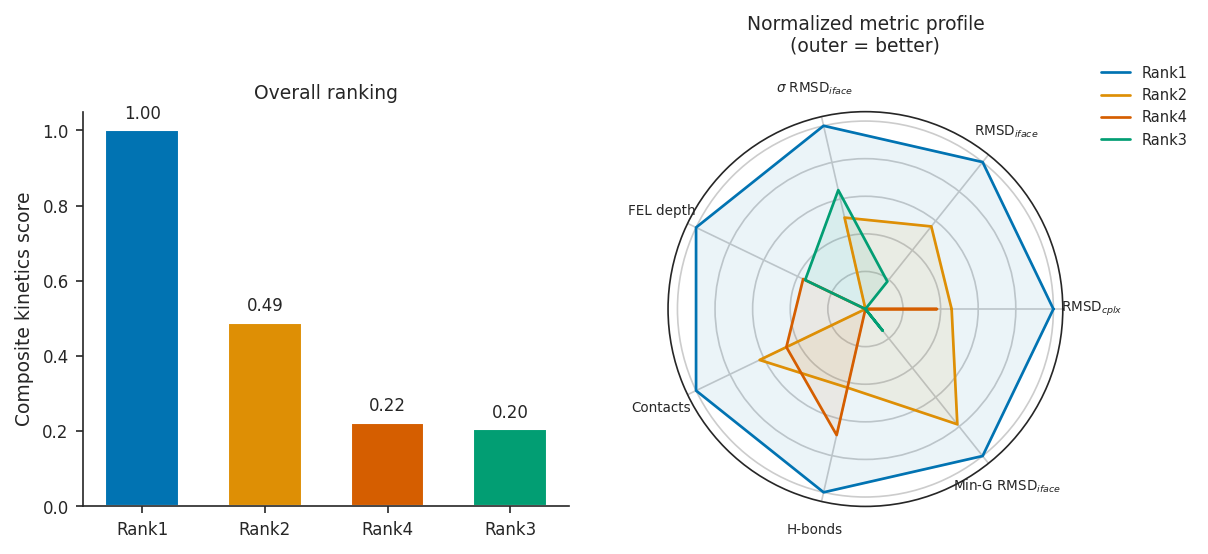

In [22]:
# @title 7.2 Plot: composite score bar chart + radar/spider chart of normalized metrics

fig = plt.figure(figsize=(8.5, 3.8))

# --- left panel: composite score bar chart ---
ax1 = fig.add_subplot(1, 2, 1)
bars = ax1.bar(ranking_df.index, ranking_df["composite_kinetics_score"],
               color=[COLORS[n] for n in ranking_df.index], width=0.6)
for bar, val in zip(bars, ranking_df["composite_kinetics_score"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
              ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("Composite kinetics score")
ax1.set_ylim(0, 1.05)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_title("Overall ranking", fontsize=9)

# --- right panel: radar chart of normalized sub-metrics ---
categories = list(METRIC_WEIGHTS.keys())
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

ax2 = fig.add_subplot(1, 2, 2, polar=True)
for name in ranking_df.index:
    values = norm_df.loc[name, categories].tolist()
    values += values[:1]
    ax2.plot(angles, values, color=COLORS[name], lw=1.3, label=name)
    ax2.fill(angles, values, color=COLORS[name], alpha=0.08)

short_labels = ["RMSD$_{cplx}$", "RMSD$_{iface}$", "$\\sigma$ RMSD$_{iface}$",
                "FEL depth", "Contacts", "H-bonds", "Min-G RMSD$_{iface}$"]
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(short_labels, fontsize=6.5)
ax2.set_yticklabels([])
ax2.set_title("Normalized metric profile\n(outer = better)", fontsize=9, y=1.12)
ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=7, frameon=False)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"07_ranking_summary.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()


## 8. Manuscript summary figure

A single composite figure combining the FEL-2 landscapes (top row) with the ranking bar chart
(bottom row), suitable as a main-text or supplementary figure. Saved at 600 DPI (PNG) and as
vector PDF for typesetting.


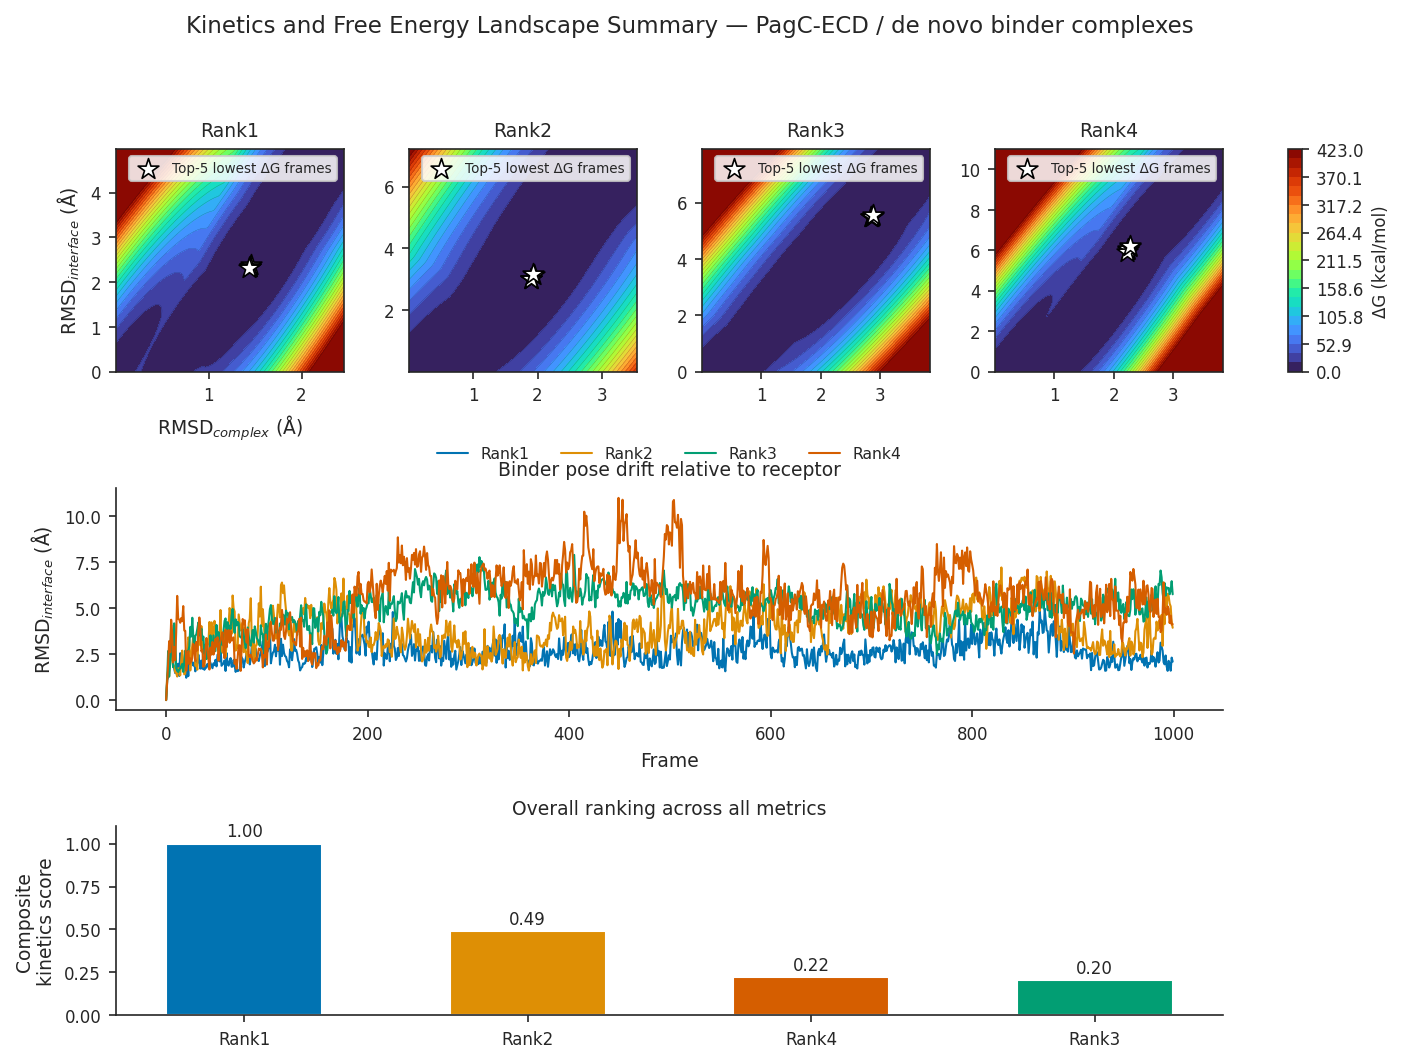

Manuscript summary figure saved as 600 DPI PNG and vector PDF in: /content/outputs/figures


In [23]:
# @title 8.1 Build composite manuscript figure

fig = plt.figure(figsize=(10.2, 7.5))
n_complexes = len(COMPLEXES)
gs = fig.add_gridspec(3, n_complexes + 1,
                       width_ratios=[1] * n_complexes + [0.06],
                       height_ratios=[1, 1, 0.85], hspace=0.55, wspace=0.35)

# Row 1: FEL-2 landscapes, one per complex
fel_axes = []
for i, name in enumerate(COMPLEXES):
    ax = fig.add_subplot(gs[0, i])
    xx, yy, G = fel2_results[name]
    df_top = top_frames_fel2[name]
    cf = plot_fel(ax, xx, yy, G,
                  xlabel="RMSD$_{complex}$ (Å)" if i == 0 else "",
                  ylabel="RMSD$_{interface}$ (Å)" if i == 0 else "",
                  title=f"{name}",
                  top_points=df_top[["rmsd_complex", "rmsd_interface"]].values)
    fel_axes.append(ax)

cbar_ax = fig.add_subplot(gs[0, -1])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label("ΔG (kcal/mol)", fontsize=8)

# Row 2: RMSD-interface time series, stacked/overlaid for direct comparison
ax_ts = fig.add_subplot(gs[1, :-1])
for name, df in metrics.items():
    ax_ts.plot(df["frame"], df["rmsd_interface"], color=COLORS[name], lw=1.0, label=name)
ax_ts.set_xlabel("Frame")
ax_ts.set_ylabel("RMSD$_{interface}$ (Å)")
ax_ts.spines[["top", "right"]].set_visible(False)
ax_ts.legend(ncol=len(COMPLEXES), loc="upper center", bbox_to_anchor=(0.5, 1.25), frameon=False)
ax_ts.set_title("Binder pose drift relative to receptor", fontsize=9)

# Row 3: composite ranking bar chart
ax_rank = fig.add_subplot(gs[2, :-1])
bars = ax_rank.bar(ranking_df.index, ranking_df["composite_kinetics_score"],
                    color=[COLORS[n] for n in ranking_df.index], width=0.55)
for bar, val in zip(bars, ranking_df["composite_kinetics_score"]):
    ax_rank.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=8)
ax_rank.set_ylabel("Composite\nkinetics score")
ax_rank.set_ylim(0, 1.1)
ax_rank.spines[["top", "right"]].set_visible(False)
ax_rank.set_title("Overall ranking across all metrics", fontsize=9)

fig.suptitle("Kinetics and Free Energy Landscape Summary — PagC-ECD / de novo binder complexes",
             fontsize=11, y=1.0)

for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"08_manuscript_summary_figure.{ext}"),
                dpi=600 if ext == "png" else None)
plt.show()

print("Manuscript summary figure saved as 600 DPI PNG and vector PDF in:", FIG_DIR)


## 9. Outputs recap

All outputs are written under `/content/outputs/`:

```
outputs/
├── figures/                         # all manuscript figures, 600 DPI PNG + vector PDF
│   ├── 01_timeseries_rmsd_rg
│   ├── 02_FEL1_rmsd_vs_rg
│   ├── 03_FEL2_rmsd_vs_interface          ← primary FEL for the manuscript
│   ├── 04_FEL3_pca
│   ├── 05_RMSF_per_residue
│   ├── 06_interface_contacts_hbonds
│   ├── 07_ranking_summary
│   └── 08_manuscript_summary_figure       ← composite figure
├── data/                             # all underlying numeric results, as CSV
│   ├── <complex>_core_metrics.csv
│   ├── <complex>_rmsf.csv
│   ├── <complex>_interface_dynamics.csv
│   ├── top5_lowest_energy_frames_ALL_complexes.csv
│   └── cross_complex_ranking_summary.csv
└── lowest_energy_frames/             # top-5 lowest-ΔG PDB structures per complex
    └── <complex>_lowestG_rank<1-5>_frame<N>.pdb
```

### Copying outputs back to Google Drive
By default everything is written to the (ephemeral) Colab VM disk at `/content/outputs`. Run
the cell below to copy the entire `outputs/` folder back to your Drive so it persists after
the runtime disconnects.


In [ ]:
# @title 9.1 (Optional) Copy outputs back to Google Drive

DRIVE_DESTINATION = "/content/drive/MyDrive/PagC_binders/FEL_analysis_outputs"  # @param {type:"string"}

import shutil
os.makedirs(DRIVE_DESTINATION, exist_ok=True)
shutil.copytree(OUTPUT_ROOT, DRIVE_DESTINATION, dirs_exist_ok=True)
print(f"Copied {OUTPUT_ROOT} -> {DRIVE_DESTINATION}")


### Notes on method choices (for your Methods section)

- RMSD and RMSF were computed on backbone atoms (N, C&alpha;, C, O) after superposition with
  the QCP algorithm (Theobald, 2005) as implemented in MDAnalysis.
- Receptor and binder were defined by residue index (receptor: residues 1&ndash;162,
  corresponding to the PagC extracellular domain; binder: residues 163 and beyond), since the
  trajectories did not retain chain identifiers.
- Free energy landscapes were estimated by Gaussian kernel density estimation (KDE, Scott's
  rule bandwidth unless overridden) over the sampled 2D collective-variable space, converted
  to free energy via &Delta;G = &minus;k<sub>B</sub>T ln P, shifted so the global minimum is 0
  kcal/mol, at the simulation temperature set in `TEMPERATURE_K` (default 300 K).
- The primary collective variables reported are complex backbone RMSD and binder-interface
  RMSD (binder backbone RMSD after rigid-body superposition on the receptor backbone only),
  chosen because they directly probe binder pose retention rather than only overall
  structural drift. A PCA-based landscape (PC1/PC2 of backbone fluctuations) is provided as a
  model-free supplementary check.
- The interface was defined as any residue with a heavy atom within the cutoff set in
  `INTERFACE_CUTOFF_A` (default 4.5 Å) of the partner chain in the first frame of each
  trajectory.
- The composite kinetics score combines min-max-normalized mean/variance of interface RMSD,
  FEL basin depth, interface contact count, interface hydrogen-bond count, and the
  interface RMSD of the globally most probable (lowest-&Delta;G) frame, equally weighted
  unless adjusted in `METRIC_WEIGHTS`.
